In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

2026-07-02 06:57:59.340593: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-02 06:58:00.092816: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-02 06:58:07.677634: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
model = keras.models.load_model(
    "CircuitSense_MobileNetV2.keras"
)

print("Model Loaded Successfully!")

I0000 00:00:1782975501.047981    1728 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3617 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model Loaded Successfully!


In [4]:
class_names = ["Ammeter",
"ac_src",
"battery",
"cap",
"curr_src",
"dc_volt_src_1",
"dc_volt_src_2",
"dep_curr_src",
"dep_volt",
"diode",
"gnd_1",
"gnd_2",
"inductor",
"resistor",
"voltmeter"]

In [5]:
component_info = {
"Ammeter":{
"Function":"Measures electric current.",
"Unit":"Ampere (A)",
"Applications":"Current measurement in circuits."
},

"ac_src":{
"Function":"Provides alternating voltage.",
"Unit":"Volt (V)",
"Applications":"AC power supply."
},

"battery":{
"Function":"Provides DC electrical energy.",
"Unit":"Volt (V)",
"Applications":"Power source."
},

"cap":{
"Function":"Stores electrical charge.",
"Unit":"Farad (F)",
"Applications":"Filtering, Timing circuits."
},

"curr_src":{
"Function":"Provides constant current.",
"Unit":"Ampere (A)",
"Applications":"Analog circuits."
},

"dc_volt_src_1":{
"Function":"Provides DC voltage.",
"Unit":"Volt (V)",
"Applications":"Power supply."
},

"dc_volt_src_2":{
"Function":"Provides DC voltage.",
"Unit":"Volt (V)",
"Applications":"Power supply."
},

"dep_curr_src":{
"Function":"Current depends on another circuit variable.",
"Unit":"Ampere (A)",
"Applications":"Circuit analysis."
},

"dep_volt":{
"Function":"Voltage depends on another circuit variable.",
"Unit":"Volt (V)",
"Applications":"Circuit analysis."
},

"diode":{
"Function":"Allows current to flow in one direction.",
"Unit":"-",
"Applications":"Rectifiers, Protection."
},

"gnd_1":{
"Function":"Ground reference.",
"Unit":"-",
"Applications":"Reference node."
},

"gnd_2":{
"Function":"Ground reference.",
"Unit":"-",
"Applications":"Reference node."
},

"inductor":{
"Function":"Stores energy in magnetic field.",
"Unit":"Henry (H)",
"Applications":"Filters, SMPS."
},

"resistor":{
"Function":"Limits current flow.",
"Unit":"Ohm (Ω)",
"Applications":"Voltage divider, Current limiting."
},

"voltmeter":{
"Function":"Measures voltage.",
"Unit":"Volt (V)",
"Applications":"Voltage measurement."
}}

In [12]:
def predict_image(image_path):

    # Load image
    img = keras.utils.load_img(
        image_path,
        target_size=(224,224))

    # Display image
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.title("Uploaded Image")
    plt.axis("off")
    plt.show()

    # Convert image
    img_array = keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array, verbose=0)[0]

    # Top 3 predictions
    top3 = np.argsort(predictions)[::-1][:3]

    best = top3[0]

    symbol = class_names[best]

    confidence = predictions[best]

    print("CircuitSense Prediction")
    print("="*60)

    print(f"\nPredicted Symbol : {symbol}")
    print(f"Confidence : {confidence*100:.2f}%")

    print("\nTop 3 Predictions")
    print("---------------------------")

    for idx in top3:
        print(f"{class_names[idx]:20} {predictions[idx]*100:.2f}%")

    print("\nComponent Information")
    print("---------------------------")

    info = component_info[symbol]

    print("Function     :", info["Function"])
    print("Unit         :", info["Unit"])
    print("Applications :", info["Applications"])
    confidence_status(confidence)

    return predictions

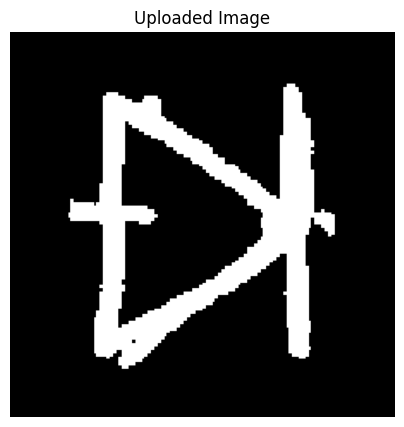

CircuitSense Prediction

Predicted Symbol : diode
Confidence : 92.79%

Top 3 Predictions
---------------------------
diode                92.79%
gnd_2                5.48%
dc_volt_src_2        0.72%

Component Information
---------------------------
Function     : Allows current to flow in one direction.
Unit         : -
Applications : Rectifiers, Protection.


array([2.0196621e-06, 5.4601078e-06, 7.5896800e-04, 7.0466083e-03,
       1.0902296e-06, 2.3468585e-04, 7.1917470e-03, 8.2886882e-06,
       1.1543824e-03, 9.2789227e-01, 1.3958006e-04, 5.4819845e-02,
       6.7827564e-06, 7.1876706e-04, 1.9511263e-05], dtype=float32)

In [8]:
predict_image("SolvaDataset_200_v3/diode/1.bmp")

In [9]:
def plot_top3(predictions):
    top3 = np.argsort(predictions)[::-1][:3]
    labels = [class_names[i] for i in top3]
    scores = [predictions[i]*100 for i in top3]
    plt.figure(figsize=(8,3))
    plt.barh(labels, scores)
    plt.xlim(0,100)
    plt.xlabel("Confidence (%)")
    plt.title("Top 3 Predictions")
    plt.gca().invert_yaxis()
    plt.show()

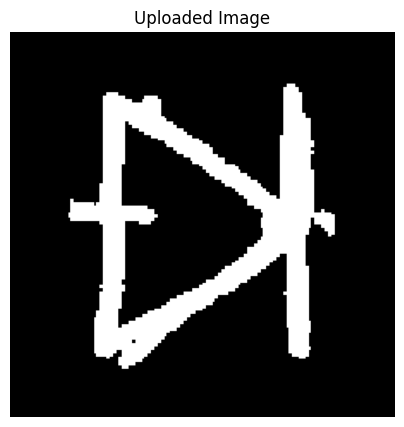

CircuitSense Prediction

Predicted Symbol : diode
Confidence : 92.79%

Top 3 Predictions
---------------------------
diode                92.79%
gnd_2                5.48%
dc_volt_src_2        0.72%

Component Information
---------------------------
Function     : Allows current to flow in one direction.
Unit         : -
Applications : Rectifiers, Protection.


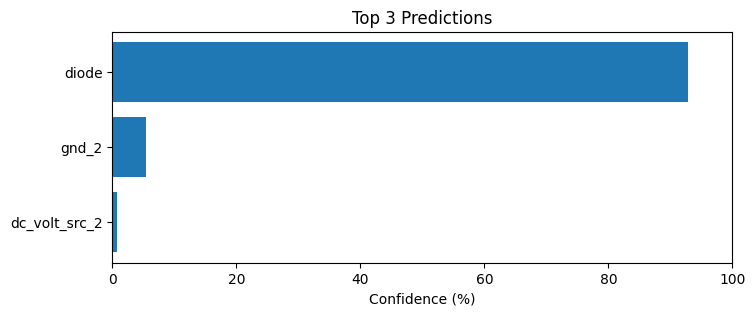

In [10]:
pred = predict_image("SolvaDataset_200_v3/diode/1.bmp")

plot_top3(pred)

In [11]:
def confidence_status(confidence):
    confidence = confidence*100
    if confidence >= 95:
        print("\nHigh Confidence Prediction")
    elif confidence >= 80:
        print("\nModerate Confidence")
    else:
        print("\nLow Confidence")